# 4 . Greeks y superficies de riesgo: `all_greeks`, `hessian`, `hvp`, `price_grid`

El motor no se limita a bump-and-reval manual: `Engine.all_greeks` barre TODAS las Greeks de
primer orden aplicables a una metrica (parametros de modelo, curva, credito, tiempo) sin que el
cliente las enumere (`PLAN_GREEKS.md SS8.5); `Engine.hessian`/`Engine.hvp` dan segundo orden
completo -- gamma pura, y cruzadas como vanna/volga -- via el metodo mas preciso disponible
para cada combinacion metrica/modelo (likelihood-ratio para GBM Monte Carlo, AAD
forward-over-forward para el NPV analitico de Hull-White). Cerramos con una superficie
precio/delta sobre (spot, volatilidad) construida con `price_grid`, mezclando una medida de
precio y una Greek en la misma rejilla.


> **Nota (`PLAN_IMPROVE_NOTEBOOK.md`, Fase 1) -- decision tomada:** `PayoffSensitivityQ` SI
> esta cableada de extremo a extremo (Rust `payoff_sensitivity_gbm_q` -> C++
> `PayoffSensitivityQMeasure::evaluate` -> `Registry<IMeasure>`), verificado por los tests C++
> `GreeksFase1Test.*MatchesPayoffSensitivityQ` (`cpp/engine/tests/test_greeks.cpp`) y
> `test_registry_wiring_payoff_measures.cpp` -- el comentario de
> `clients/python/tests/test_registry.py` ("item pendiente cablear ... al bridge cxx") es
> HISTORICO (de cuando la medida se anadio en la Fase 11 de `PLAN_PRODUCTS.md`), no una tarea
> pendiente hoy.
>
> Decision de diseno explicita (parrafo "Tareas de motor" de la Fase 1): para las 4
> sensibilidades que cubre (`greek="spot"|"rate"|"dividend_yield"|"volatility"`, GBM unicamente)
> `PayoffSensitivityQ` es un ALIAS/ruta legado de
> `Greek(metric="PayoffPriceQ", method="pathwise")` -- ambas llaman literalmente a la misma
> funcion Rust `payoff::payoff_sensitivity_gbm` (ver `try_pathwise` en `cpp/engine/src/
> greeks.cpp`), asi que **no se anade wrapper propio en `engine_typed`**: la ruta recomendada
> para clientes Python sigue siendo `greeks.delta/vega/rho(...)`. `PayoffSensitivityQ` queda
> alcanzable directamente por nombre para quien la necesite sin pasar por `Greek`:
> `eng.price(product, [("PayoffSensitivityQ", {"greek": "spot"})], model, market, pricing,
> execution)`. La celda de la seccion 1b (justo despues de esta) compara ambas rutas sobre la
> misma call ATM.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "../../../build/clients/python")
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

import engine
import engine_typed as q
from engine_typed import greeks

print("modulo engine importado desde:", engine.__file__)


modulo engine importado desde: S:\Projects\engine_quant\clients\python\notebooks\../../../build/clients/python\engine.cp312-win_amd64.pyd


## 1. `all_greeks`: barrido automatico sobre una call GBM


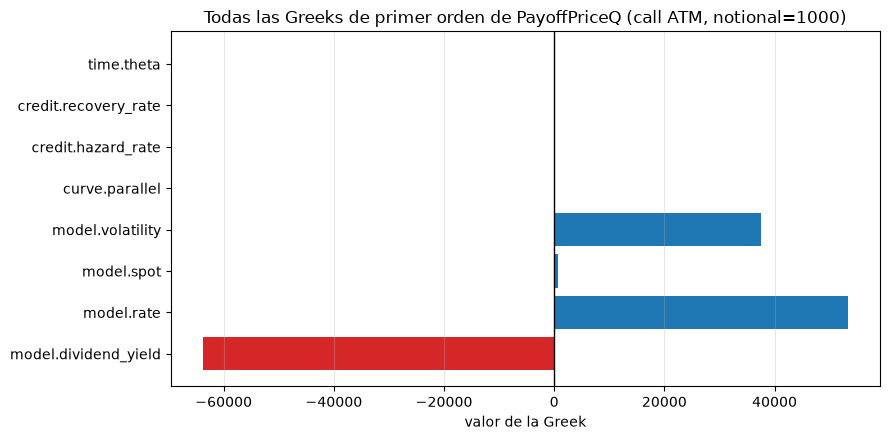

model.dividend_yield   =   -63,750.7199  (metodo=pathwise, medida=RiskNeutralQ)
model.rate             =    53,286.9211  (metodo=pathwise, medida=RiskNeutralQ)
model.spot             =       637.5072  (metodo=pathwise, medida=RiskNeutralQ)
model.volatility       =    37,563.4678  (metodo=pathwise, medida=RiskNeutralQ)
curve.parallel         =         0.0000  (metodo=bump_and_reval, medida=RiskNeutralQ)
credit.hazard_rate     =         0.0000  (metodo=bump_and_reval, medida=RiskNeutralQ)
credit.recovery_rate   =         0.0000  (metodo=bump_and_reval, medida=RiskNeutralQ)
time.theta             =       -17.5989  (metodo=bump_and_reval, medida=RiskNeutralQ)


In [2]:
OBS = "EQ.SPOT.AAPL"
S0, K, R, Q_DIV, SIGMA, T = 100.0, 100.0, 0.05, 0.0, 0.20, 1.0

eng = engine.Engine()
trade = q.european_call("AAPL_CALL_100", OBS, strike=K, notional=1_000.0, maturity=T)
product = eng.create_product(trade.product_type, trade.to_params())
model = eng.create_model("GBM", {"s0": S0, "r": R, "q": Q_DIV, "sigma": SIGMA, "observable": OBS})
market = engine.MarketSnapshot(pillars=[T], zero_rates=[R])
pricing = engine.PricingContext({"pricing_date": 0.0, "n_paths": 200_000.0, "n_steps": 1.0, "seed": 7.0})
execution = engine.ExecutionContext({"backend": "cpu"})

report = eng.all_greeks(product, "PayoffPriceQ", model, market, pricing, execution)

names = [g.risk_factor for g in report.greeks]
values = [g.value for g in report.greeks]

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["tab:red" if v < 0 else "tab:blue" for v in values]
ax.barh(names, values, color=colors)
ax.axvline(0.0, color="black", linewidth=1)
ax.set_xlabel("valor de la Greek")
ax.set_title("Todas las Greeks de primer orden de PayoffPriceQ (call ATM, notional=1000)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

for g in report.greeks:
    print(f"{g.risk_factor:<22} = {g.value:>14,.4f}  (metodo={g.method_used}, medida={g.measure})")
if report.skipped:
    print("Omitidas:", report.skipped)


## 1b. `PayoffSensitivityQ` vs `Greek` pathwise: la misma simulacion, dos nombres

Ver la nota de la Fase 1 mas arriba: para `greek` en `{"spot", "rate", "dividend_yield",
"volatility"}` sobre un modelo `GBM`, `PayoffSensitivityQ` y `Greek(metric="PayoffPriceQ",
method="pathwise")` invocan la MISMA funcion Rust (`payoff_sensitivity_gbm`) con el mismo
`model`/`product`/`seed`/`n_paths` -- por eso la comparacion de abajo usa una tolerancia mucho
mas ajustada que el resto del notebook (es la misma simulacion evaluada dos veces, no dos
simulaciones Monte Carlo independientes), mismo patron "una ruta del motor contra otra" que el
notebook `01` usa contra Black-Scholes cerrado.


In [3]:
comparisons = [
    ("spot", "delta", greeks.delta("PayoffPriceQ", "spot").to_spec()),
    ("volatility", "vega", greeks.vega("PayoffPriceQ").to_spec()),
    ("rate", "rho", greeks.rho("PayoffPriceQ").to_spec()),
    ("dividend_yield", "d/dq", greeks.delta("PayoffPriceQ", "dividend_yield").to_spec()),
]

print(f"{'greek':<16}{'label':<8}{'Greek (pathwise)':>20}{'PayoffSensitivityQ':>22}{'diff':>16}")
for greek_name, label, greek_spec in comparisons:
    via_greek = eng.price(product, [greek_spec], model, market, pricing, execution)["Greek"].scalar
    via_sensitivity = eng.price(
        product, [("PayoffSensitivityQ", {"greek": greek_name})], model, market, pricing, execution
    )["PayoffSensitivityQ"].scalar
    diff = via_greek - via_sensitivity
    print(f"{greek_name:<16}{label:<8}{via_greek:>20,.6f}{via_sensitivity:>22,.6f}{diff:>16.8f}")
    assert abs(diff) < 1e-6, f"{greek_name}: Greek={via_greek} PayoffSensitivityQ={via_sensitivity}"

print("\nOK: PayoffSensitivityQ coincide con Greek(method='pathwise') hasta precision numerica\n"
      "(misma funcion Rust, mismo seed) para las 4 sensibilidades de GBM que cubre -- confirma la\n"
      "decision de la nota de arriba: es un alias, no una ruta con valor propio.")


greek           label       Greek (pathwise)    PayoffSensitivityQ            diff
spot            delta             637.507199            637.507199      0.00000000


volatility      vega           37,563.467810         37,563.467810      0.00000000
rate            rho            53,286.921131         53,286.921131      0.00000000


dividend_yield  d/dq          -63,750.719936        -63,750.719936      0.00000000

OK: PayoffSensitivityQ coincide con Greek(method='pathwise') hasta precision numerica
(misma funcion Rust, mismo seed) para las 4 sensibilidades de GBM que cubre -- confirma la
decision de la nota de arriba: es un alias, no una ruta con valor propio.


## 2. Gamma pura de cada parametro (`include_second_order=True`)


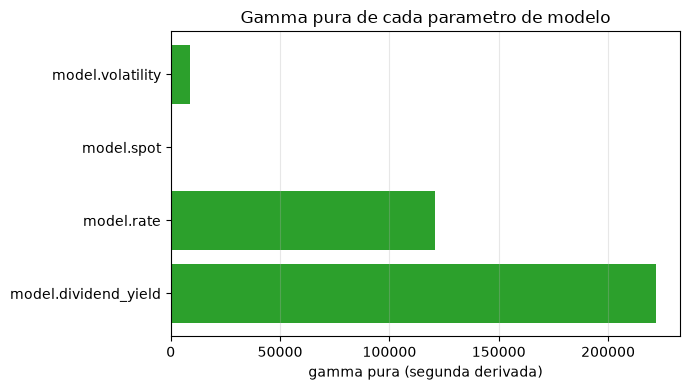

In [4]:
report_2nd = eng.all_greeks(product, "PayoffPriceQ", model, market, pricing, execution, include_second_order=True)
gammas = [g for g in report_2nd.greeks if g.order == 2]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh([g.risk_factor for g in gammas], [g.value for g in gammas], color="tab:green")
ax.set_xlabel("gamma pura (segunda derivada)")
ax.set_title("Gamma pura de cada parametro de modelo")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


## 3. Matriz Hessiana completa: gamma, vanna, volga

`Engine.hessian` da la matriz simetrica completa de segundas derivadas cruzadas
(`spot-spot`=gamma, `volatility-volatility`=volga, `spot-volatility`=vanna) sobre una call GBM,
via likelihood-ratio en una unica pasada Monte Carlo (`method_used="likelihood_ratio_hessian"`).


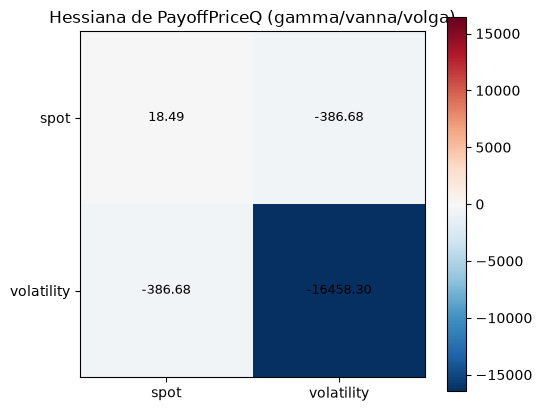

d2/dmodel.spot.dmodel.spot =      18.4857  (metodo=likelihood_ratio_hessian, std_error=0.3007)
d2/dmodel.volatility.dmodel.volatility = -16,458.3010  (metodo=likelihood_ratio_hessian, std_error=15689.1898)
d2/dmodel.spot.dmodel.volatility =    -386.6825  (metodo=likelihood_ratio_hessian, std_error=64.5064)


In [5]:
hessian_report = eng.hessian(product, "PayoffPriceQ", model, market, pricing, execution)

factors = sorted({e.factor_i for e in hessian_report.entries} | {e.factor_j for e in hessian_report.entries})
matrix = np.full((len(factors), len(factors)), np.nan)
index = {f: i for i, f in enumerate(factors)}
for e in hessian_report.entries:
    i, j = index[e.factor_i], index[e.factor_j]
    matrix[i, j] = e.value
    matrix[j, i] = e.value

short_labels = [f.replace("model.", "") for f in factors]

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(matrix, cmap="RdBu_r", vmin=-np.nanmax(np.abs(matrix)), vmax=np.nanmax(np.abs(matrix)))
ax.set_xticks(range(len(factors)), short_labels)
ax.set_yticks(range(len(factors)), short_labels)
for i in range(len(factors)):
    for j in range(len(factors)):
        ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Hessiana de PayoffPriceQ (gamma/vanna/volga)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

for e in hessian_report.entries:
    print(f"d2/d{e.factor_i}.d{e.factor_j} = {e.value:>12,.4f}  (metodo={e.method_used}, std_error={e.std_error:.4f})")


## 4. HVP: producto Hessiana-vector en una direccion concreta

`Engine.hvp` evita materializar toda la matriz cuando solo interesa una combinacion de
factores de riesgo -- aqui se verifica que coincide exactamente con la fila `spot` de la
Hessiana de arriba.


In [6]:
hvp_report = eng.hvp(
    product, "PayoffPriceQ", model, market, pricing, execution,
    direction={"model.spot": 1.0, "model.volatility": 0.0},
)
by_pair = {(e.factor_i, e.factor_j): e.value for e in hessian_report.entries}
hessian_row_spot = {
    "model.spot": by_pair[("model.spot", "model.spot")],
    "model.volatility": by_pair.get(("model.spot", "model.volatility"), by_pair.get(("model.volatility", "model.spot"))),
}
print(f"{'factor':<20}{'HVP':>14}{'fila Hessiana':>16}")
for c in hvp_report.components:
    print(f"{c.factor:<20}{c.value:>14,.4f}{hessian_row_spot[c.factor]:>16,.4f}")


factor                         HVP   fila Hessiana
model.spot                 18.4857         18.4857
model.volatility         -386.6825       -386.6825


## 5. Hessiana de un swap Hull-White: AAD forward-over-forward

Sobre `HullWhiteModelNpv` (NPV que si depende del modelo, PLAN_GREEKS.md SS7) con un swap IRS,
la Hessiana completa de los 4 parametros (`a`, `b`, `sigma`, `r0`) se calcula via
diferenciacion automatica forward-over-forward -- sin ningun bump-and-reval, ver
`method_used`.


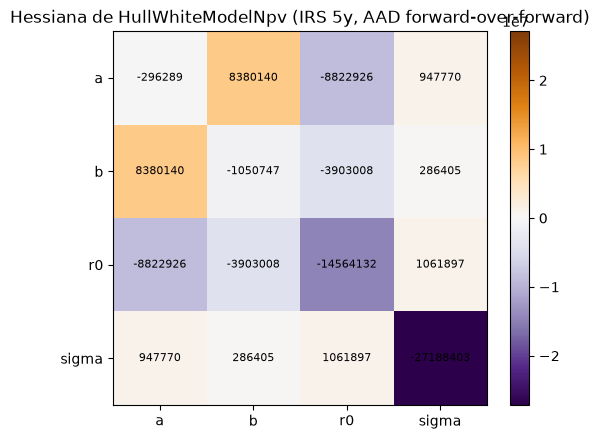

metodos usados: {'aad_forward_over_forward'}
numero de entradas (simetria: 4 diagonales + 6 cruzadas): 10


In [7]:
hw_model = eng.create_model("HullWhite1F", {"a": 0.1, "b": 0.03, "sigma": 0.01, "r0": 0.02})
hw_trade = q.IRSwap(
    notional=1_000_000.0, fixed_rate=0.02,
    payment_times=[1.0, 2.0, 3.0, 4.0, 5.0], accruals=[1.0] * 5,
)
hw_product = eng.create_product(hw_trade.product_type, hw_trade.to_params())
hw_market = engine.MarketSnapshot(pillars=[1.0, 2.0], zero_rates=[0.02, 0.02])
hw_pricing = engine.PricingContext({"pricing_date": 0.0, "n_paths": 1000.0, "n_steps": 1.0, "seed": 7.0})

hw_hessian = eng.hessian(hw_product, "HullWhiteModelNpv", hw_model, hw_market, hw_pricing, execution)

hw_factors = sorted({e.factor_i for e in hw_hessian.entries} | {e.factor_j for e in hw_hessian.entries})
hw_matrix = np.zeros((len(hw_factors), len(hw_factors)))
hw_index = {f: i for i, f in enumerate(hw_factors)}
for e in hw_hessian.entries:
    i, j = hw_index[e.factor_i], hw_index[e.factor_j]
    hw_matrix[i, j] = e.value
    hw_matrix[j, i] = e.value

hw_labels = [f.replace("model.", "") for f in hw_factors]
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(hw_matrix, cmap="PuOr_r", vmin=-np.max(np.abs(hw_matrix)), vmax=np.max(np.abs(hw_matrix)))
ax.set_xticks(range(len(hw_factors)), hw_labels)
ax.set_yticks(range(len(hw_factors)), hw_labels)
for i in range(len(hw_factors)):
    for j in range(len(hw_factors)):
        ax.text(j, i, f"{hw_matrix[i, j]:.0f}", ha="center", va="center", fontsize=8)
ax.set_title("Hessiana de HullWhiteModelNpv (IRS 5y, AAD forward-over-forward)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print("metodos usados:", {e.method_used for e in hw_hessian.entries})
print("numero de entradas (simetria: 4 diagonales + 6 cruzadas):", len(hw_hessian.entries))


## 6. Superficie precio/delta sobre (spot, volatilidad) via `price_grid`

`price_grid` acepta una mezcla de medidas de precio y Greeks en la MISMA rejilla de modelos --
cada celda `(trade, model, market)` se revalora una sola vez y ambas medidas comparten esa
simulacion. Aqui la rejilla de "modelos" recorre una malla de `(spot, sigma)`.


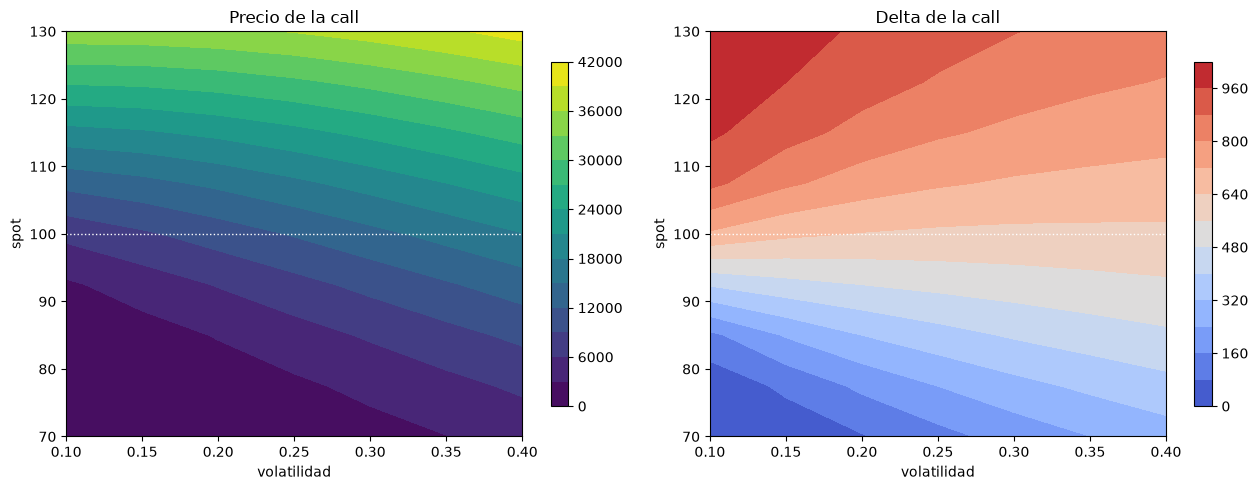

In [8]:
spot_grid = np.linspace(70.0, 130.0, 9)
vol_grid = np.linspace(0.10, 0.40, 7)

surface_models = []
for s in spot_grid:
    for v in vol_grid:
        surface_models.append(eng.create_model("GBM", {"s0": float(s), "r": R, "q": Q_DIV, "sigma": float(v), "observable": OBS}))

surface_pricing = engine.PricingContext({"pricing_date": 0.0, "n_paths": 30_000.0, "n_steps": 1.0, "seed": 11.0})
grid = eng.price_grid(
    [product], ["PayoffPriceQ", greeks.delta("PayoffPriceQ", "spot").to_spec()],
    surface_models, [market], surface_pricing, execution,
)

price_surface = np.zeros((len(spot_grid), len(vol_grid)))
delta_surface = np.zeros((len(spot_grid), len(vol_grid)))
for cell in grid:
    i, j = divmod(cell.model_index, len(vol_grid))
    price_surface[i, j] = cell.measures["PayoffPriceQ"].scalar
    delta_surface[i, j] = cell.measures["Greek"].scalar

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, surf, title, cmap in [
    (axes[0], price_surface, "Precio de la call", "viridis"),
    (axes[1], delta_surface, "Delta de la call", "coolwarm"),
]:
    im = ax.contourf(vol_grid, spot_grid, surf, levels=15, cmap=cmap)
    ax.axhline(K, color="white", linestyle=":", linewidth=1)
    ax.set_xlabel("volatilidad")
    ax.set_ylabel("spot")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()
